## When dealing with data, always consider what we are working with first


In [1]:
import csv 
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv('data/german_credit_data.csv')

df.shape
df.describe
df.columns

c:\Users\fredy\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.stats import gaussian_kde


Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [2]:
#Lets take some features based on what seems important

#Saving accounts, Checking account, Credit amount, Age

#Cleaning dataset in saving/checking account 
# df['Result'] = df['']
print(df.head)

<bound method NDFrame.head of      Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0             0   67    male    2     own             NaN           little   
1             1   22  female    2     own          little         moderate   
2             2   49    male    1     own          little              NaN   
3             3   45    male    2    free          little           little   
4             4   53    male    2    free          little           little   
..          ...  ...     ...  ...     ...             ...              ...   
995         995   31  female    1     own          little              NaN   
996         996   40    male    3     own          little           little   
997         997   38    male    2     own          little              NaN   
998         998   23    male    2    free          little           little   
999         999   27    male    2     own        moderate         moderate   

     Credit amount  Duration     

In [ ]:
df["Job"].unique() 
#Only 3 types of jobs 

array([2, 1, 3, 0])

In [8]:

df.fillna('-1', inplace=True)
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [15]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Credit amount'}>],
       [<Axes: title={'center': 'Duration'}>, <Axes: >]], dtype=object)

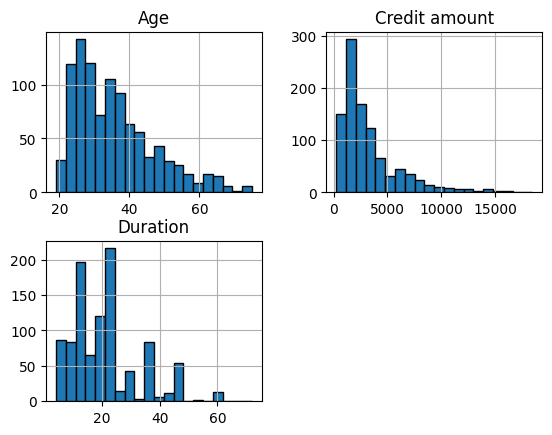

In [19]:
# df.drop(columns='Unnamed: 0', inplace=True)
df.columns
df[['Age', 'Credit amount', 'Duration']].hist(bins=20, edgecolor='black')

In [23]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

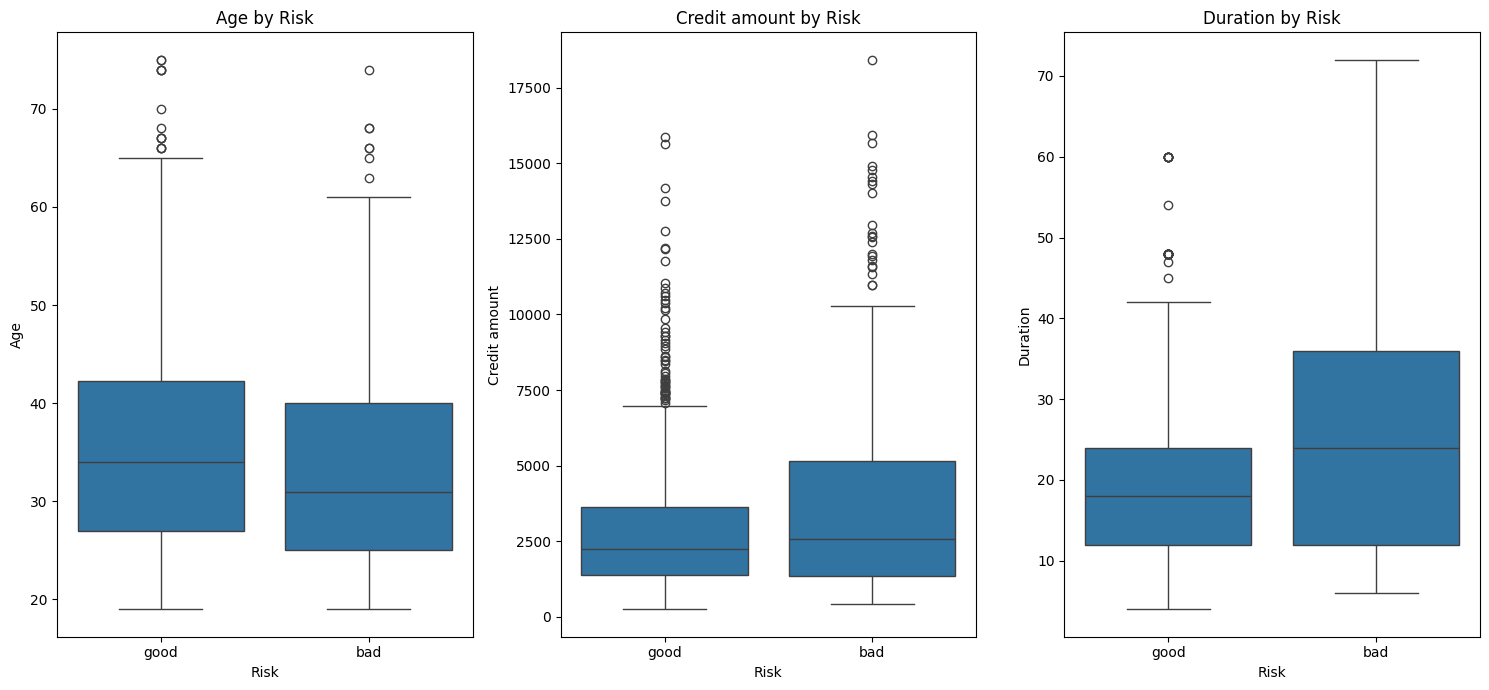

In [30]:
plt.figure(figsize=(15, 7))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x = "Risk", y = col)
    plt.title(f"{col} by Risk")


plt.tight_layout()
plt.show()

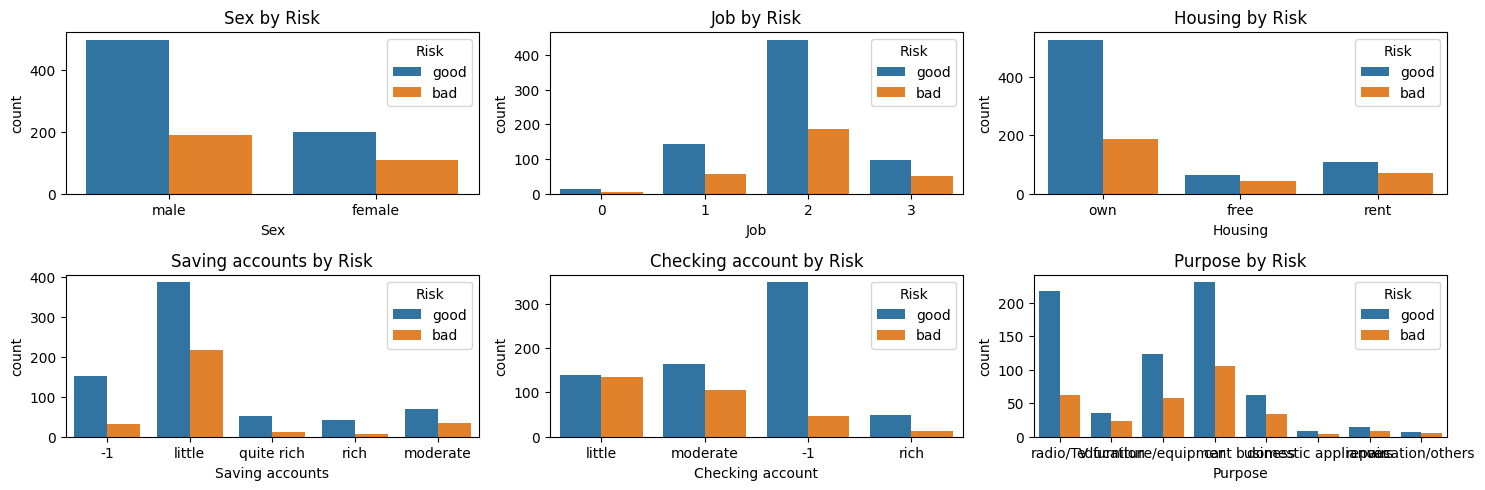

In [35]:
#Duration seems relevant, so does credit amount 

categorical = ['Sex', 'Job','Housing', 'Saving accounts', 'Checking account', 'Purpose']
plt.figure(figsize=(15, 7))
for i, col in enumerate(categorical):
    plt.subplot(3, 3, i+1)
    sns.countplot(data = df, x = col, hue="Risk")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [47]:
training_df = df
training_df = training_df.drop(columns="Risk")
print(training_df.columns)

print(training_df.head())

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='str')
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own              -1           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little               -1           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  
0         6             radio/TV  
1        48             radio/TV  
2        12            education  
3        42  furniture/equipment  
4        24                  car  


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
7,7,35,male,3,rent,little,moderate,6948,36,car,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
993,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
